# 01 - Exploracion de datos: Diabetes Prediction Dataset

Sistema de prediccion de riesgo de Diabetes Mellitus Tipo 2 mediante Machine Learning.

Este notebook corresponde a la etapa de **Comprension de los datos** del proceso CRISP-DM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

df = pd.read_csv('data/diabetes_prediction_dataset.csv')
print('Registros originales:', df.shape[0])
print('Columnas:', df.shape[1])
df.head()

Registros originales: 100000
Columnas: 9


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 1. Filtrado por poblacion objetivo (30 a 64 anios)

In [2]:
df = df[(df['age'] >= 30) & (df['age'] <= 64)].reset_index(drop=True)
print('Registros luego del filtro (30-64 anios):', df.shape[0])
df.describe()

Registros luego del filtro (30-64 anios): 48997


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,48997.000000,48997.000000,48997.000000,48997.000000,48997.000000,48997.000000,48997.000000
mean,47.215523,0.081576,0.028349,29.301565,5.539835,138.363798,0.090373
std,9.783254,0.273721,0.165969,6.348413,1.073569,41.118318,0.286718
min,30.000000,0.000000,0.000000,10.080000,3.500000,80.000000,0.000000
25%,39.000000,0.000000,0.000000,26.280000,4.800000,100.000000,0.000000
50%,47.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,55.000000,0.000000,0.000000,31.700000,6.200000,159.000000,0.000000
max,64.000000,1.000000,1.000000,91.820000,9.000000,300.000000,1.000000


## 2. Calidad de datos: nulos y duplicados

In [3]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Filas duplicadas:', df.duplicated().sum())

Valores nulos por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Filas duplicadas: 1681


## 3. Balance de clases (variable objetivo: diabetes)

Como se identifico previamente, el dataset presenta un desbalance de clases considerable.

diabetes
0    44569
1     4428
Name: count, dtype: int64

diabetes
0    90.96
1     9.04
Name: proportion, dtype: float64


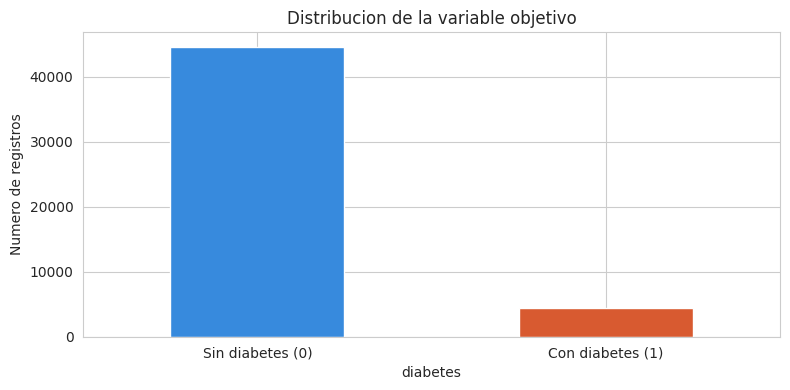

In [4]:
counts = df['diabetes'].value_counts()
pct = df['diabetes'].value_counts(normalize=True) * 100
print(counts)
print()
print(pct.round(2))

fig, ax = plt.subplots()
counts.plot(kind='bar', ax=ax, color=['#378ADD', '#D85A30'])
ax.set_xticklabels(['Sin diabetes (0)', 'Con diabetes (1)'], rotation=0)
ax.set_ylabel('Numero de registros')
ax.set_title('Distribucion de la variable objetivo')
plt.tight_layout()
plt.show()

## 4. Distribucion de variables numericas segun diagnostico

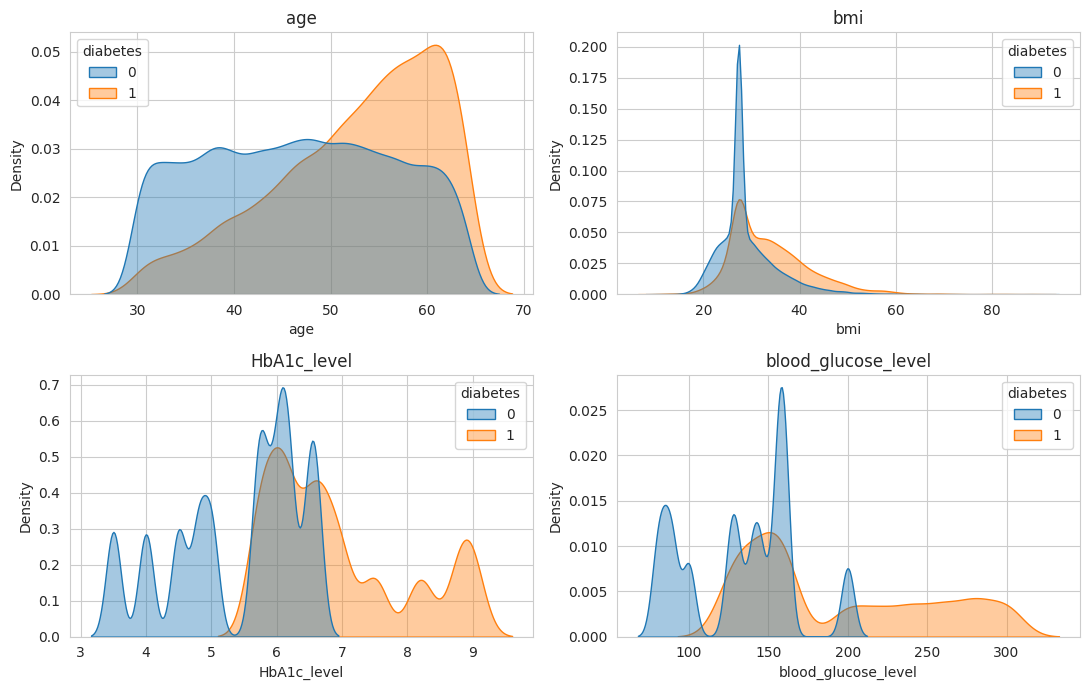

In [5]:
num_vars = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flatten(), num_vars):
    sns.kdeplot(data=df, x=col, hue='diabetes', fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Variables categoricas y binarias vs diabetes

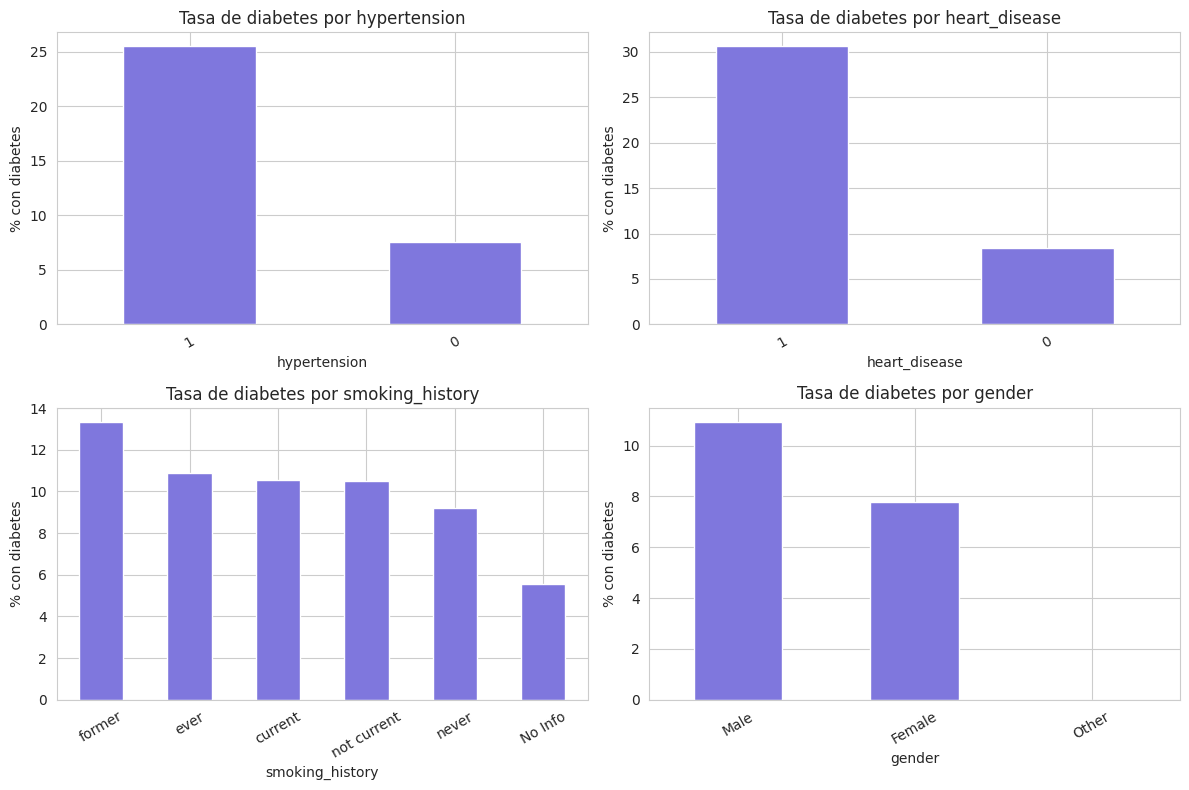

In [6]:
cat_vars = ['hypertension', 'heart_disease', 'smoking_history', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cat_vars):
    rate = df.groupby(col)['diabetes'].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='#7F77DD')
    ax.set_ylabel('% con diabetes')
    ax.set_title(f'Tasa de diabetes por {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Matriz de correlacion (variables numericas)

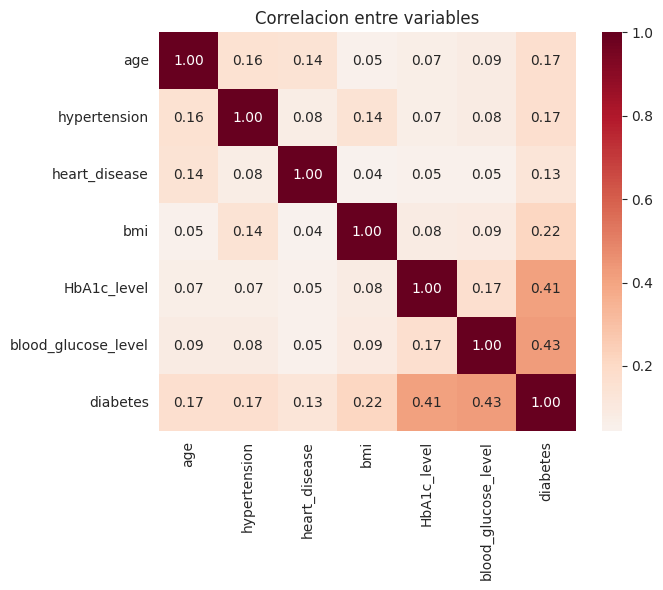

In [7]:
corr_vars = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlacion entre variables')
plt.tight_layout()
plt.show()

## 7. Hallazgos principales

- El dataset filtrado (30-64 anios) contiene el numero de registros indicado en la seccion 1, con una proporcion de casos positivos minoritaria (desbalance de clases), lo que se abordara en la etapa de preparacion de datos (notebook 02) mediante tecnicas de balanceo (class_weight o SMOTE).
- No se identifican valores nulos. Se identificaron 1,681 filas duplicadas (~3.4% del subconjunto filtrado), las cuales seran eliminadas en la etapa de preparacion de datos (notebook 02) para evitar sesgos en el entrenamiento.
- Las variables `HbA1c_level` y `blood_glucose_level` muestran la asociacion mas fuerte con la variable objetivo, consistente con su rol clinico como indicadores directos de diabetes.
- `hypertension`, `heart_disease` y `age` muestran una asociacion moderada.
- `smoking_history` y `gender` presentan diferencias mas leves en la tasa de diabetes.

Estos hallazgos orientan la seleccion de variables y el tratamiento a aplicar en la etapa de preparacion de datos, previa al entrenamiento de los modelos (notebook 02).